In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc

# Load the parquet file (adjust the path if your folder structure changed)
file_path = 'ml_features_1m_v2.parquet'
df = pd.read_parquet(file_path)

# Initial preprocessing from your first notebook
df['minute_bar'] = pd.to_datetime(df['minute_bar'])
df = df.sort_values('minute_bar')
df = df.fillna(0)

print(f"Data loaded successfully! Shape: {df.shape}")

Data loaded successfully! Shape: (5587547, 16)


In [2]:
# ==========================================
# STEP 1: Optimized Feature Selection & Engineering
# ==========================================
import pandas as pd

# 1. Discard inactive volume variables (from Feature Importance analysis)
useless_features = [
    'total_volume', 'buy_volume', 'sell_volume', 
    'trade_count', 'order_flow_imbalance', 'bar_volatility'
]
df_opt = df.drop(columns=useless_features)

# 2. Create Temporal Deltas (e.g., depth imbalance variation)
# Sorting chronologically just in case (though you did this earlier)
df_opt = df_opt.sort_values('minute_bar')
df_opt['depth_imbalance_delta_1m'] = df_opt['depth_imbalance'].diff()

# 3. Create Exponential Moving Averages (EMA)
df_opt['close_mid_ema_5'] = df_opt['close_mid'].ewm(span=5, adjust=False).mean()
df_opt['mean_spread_ema_5'] = df_opt['mean_spread'].ewm(span=5, adjust=False).mean()

# Drop missing values generated by the diff() and EMA shifts
df_opt = df_opt.dropna()

# Redefine X and y with the new optimized dataset
drop_columns_opt = ['market_id', 'minute_bar', 'target']
X_opt = df_opt.drop(columns=drop_columns_opt)
y_opt = df_opt['target']

# Chronological split for the new optimized data
split_idx = int(len(df_opt) * 0.8)
X_train_opt, X_test_opt = X_opt.iloc[:split_idx], X_opt.iloc[split_idx:]
y_train_opt, y_test_opt = y_opt.iloc[:split_idx], y_opt.iloc[split_idx:]

print(f"Optimized Training data shape: {X_train_opt.shape}")
print(f"Optimized Testing data shape: {X_test_opt.shape}")

Optimized Training data shape: (4470036, 10)
Optimized Testing data shape: (1117510, 10)


In [3]:
# ==========================================
# STEP 2: Time Series Cross-Validation
# ==========================================
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Iniciando Time Series Cross-Validation (Walk-Forward)...")
tscv = TimeSeriesSplit(n_splits=5)

# We will test this on the best model from your previous runs: LightGBM
best_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    verbose=-1
)

cv_metrics = {'ROC-AUC': [], 'F1-Score': []}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_opt), start=1):
    X_tr, X_val = X_train_opt.iloc[train_idx], X_train_opt.iloc[val_idx]
    y_tr, y_val = y_train_opt.iloc[train_idx], y_train_opt.iloc[val_idx]
    
    best_model.fit(X_tr, y_tr)
    
    preds = best_model.predict(X_val)
    probs = best_model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, probs)
    f1 = f1_score(y_val, preds, zero_division=0)
    
    cv_metrics['ROC-AUC'].append(auc)
    cv_metrics['F1-Score'].append(f1)
    print(f"Fold {fold} - ROC-AUC: {auc:.4f} | F1-Score: {f1:.4f}")

print(f"\nMédia ROC-AUC (TSCV): {np.mean(cv_metrics['ROC-AUC']):.4f}")

Iniciando Time Series Cross-Validation (Walk-Forward)...
Fold 1 - ROC-AUC: 0.8894 | F1-Score: 0.6661
Fold 2 - ROC-AUC: 0.9115 | F1-Score: 0.7041
Fold 3 - ROC-AUC: 0.9025 | F1-Score: 0.6689
Fold 4 - ROC-AUC: 0.9236 | F1-Score: 0.7024
Fold 5 - ROC-AUC: 0.9136 | F1-Score: 0.6762

Média ROC-AUC (TSCV): 0.9081


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[169]	valid_0's binary_logloss: 0.364019


<Figure size 800x600 with 0 Axes>

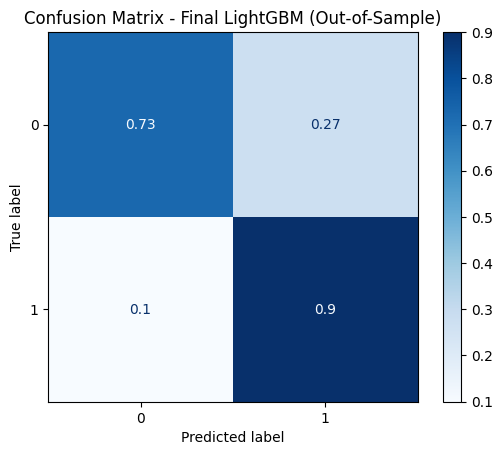

In [4]:
# ==========================================
# STEP 3: Out-of-Sample Validation & Confusion Matrix
# ==========================================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train final model on the full optimized training set
final_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    verbose=-1
)

final_model.fit(
    X_train_opt, y_train_opt,
    eval_set=[(X_test_opt, y_test_opt)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# Out-of-sample predictions
final_preds = final_model.predict(X_test_opt)
final_probs = final_model.predict_proba(X_test_opt)[:, 1]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_opt, 
    final_preds, 
    cmap='Blues', 
    normalize='true' # Normalizing to show percentages makes financial analysis easier
)
plt.title("Confusion Matrix - Final LightGBM (Out-of-Sample)")
plt.show()

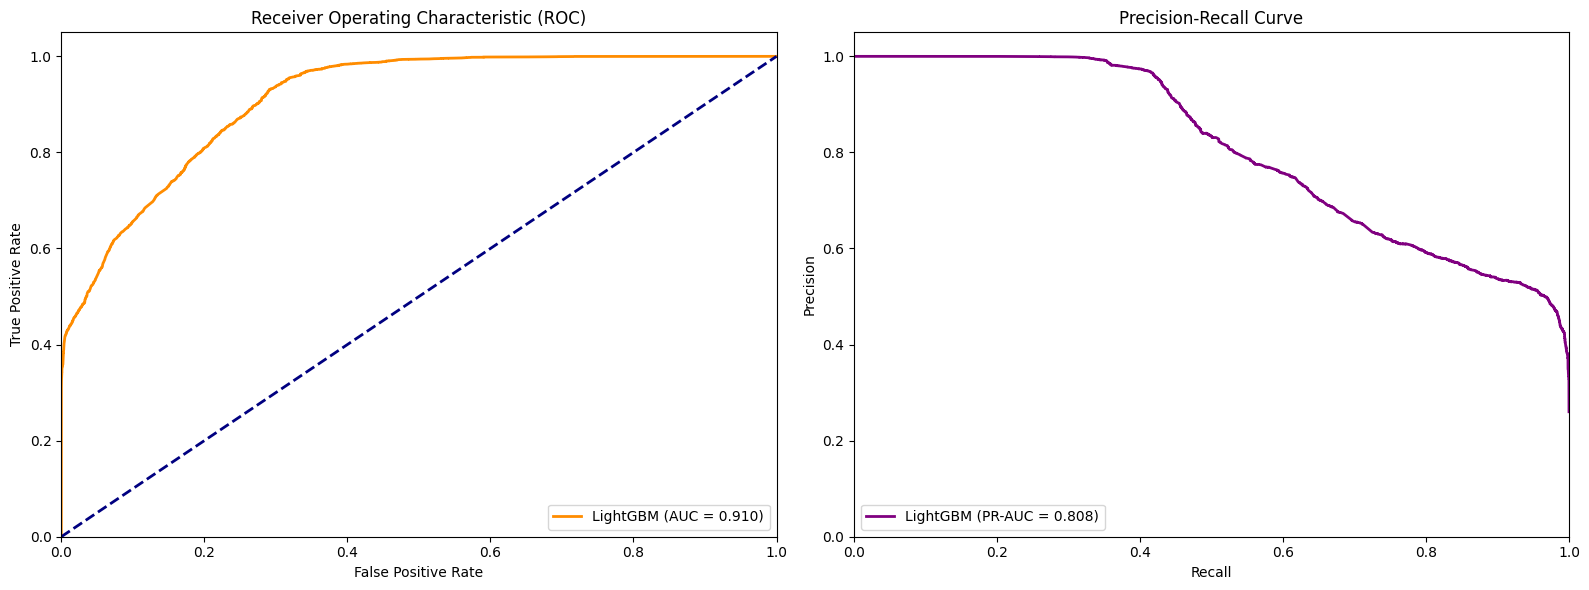

In [5]:
# ==========================================
# STEP 4: ROC & Precision-Recall Curves
# ==========================================
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Assuming you want to plot the final model's curves
fpr, tpr, _ = roc_curve(y_test_opt, final_probs)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_opt, final_probs)
pr_auc = auc(recall, precision)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'LightGBM (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# Precision-Recall Curve
ax2.plot(recall, precision, color='purple', lw=2, label=f'LightGBM (PR-AUC = {pr_auc:.3f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()